In [ ]:
from pyspark.sql import SparkSession
from pathlib import Path
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
from pyspark.sql.window import Window


file_path = Path.cwd()
data_path = file_path.parent / "output" / "cleaned.parquet"

spark = (
    SparkSession.builder.appName("clickstream-exploration")
    .master("local[*]")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
df = spark.read.parquet(str(data_path))
df.printSchema()

root
 |-- order: integer (nullable = true)
 |-- country: integer (nullable = true)
 |-- session_id: integer (nullable = true)
 |-- page_1_main_category: string (nullable = true)
 |-- page_2_clothing_model: string (nullable = true)
 |-- colour: string (nullable = true)
 |-- location: string (nullable = true)
 |-- model_photography: string (nullable = true)
 |-- price: integer (nullable = true)
 |-- price_2: boolean (nullable = true)
 |-- page: integer (nullable = true)
 |-- date: date (nullable = true)



In [2]:
# constants
eu_codes = [
    2,
    3,
    8,
    9,
    10,
    11,
    14,
    15,
    16,
    17,
    18,
    21,
    22,
    23,
    24,
    25,
    27,
    30,
    34,
    35,
    36,
    37,
    41,
]
non_eu_europe_codes = [7, 19, 28, 31, 32, 33, 38, 39]
outside_europe_codes = [1, 4, 5, 6, 20, 26, 40, 42]
unidentified_codes = [12, 43, 44, 45, 46, 47]

colour_map = {
    1: "beige",
    2: "black",
    3: "blue",
    4: "brown",
    5: "burgundy",
    6: "gray",
    7: "green",
    8: "navy blue",
    9: "many colors",
    10: "olive",
    11: "pink",
    12: "red",
    13: "violet",
    14: "white",
}

plot_colour_map = {
    "beige": "beige",
    "black": "black",
    "blue": "blue",
    "brown": "brown",
    "burgundy": "#800020",
    "gray": "gray",
    "green": "green",
    "navy blue": "navy",
    "many colors": "gold",
    "olive": "olive",
    "pink": "pink",
    "red": "red",
    "violet": "violet",
    "white": "white",
}


import matplotlib.pyplot as plt


def plot_df(
    df,
    x=None,
    y=None,
    kind="line",
    figsize=(8, 5),
    xlabel=None,
    ylabel=None,
    title=None,
    rotation=0,
    grid=False,
    legend=True,
    **kwargs
):
    """
    Reusable plotting function for pandas DataFrames.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame to plot from.
    x : str, optional
        Column for x-axis.
    y : str or list[str], optional
        Column(s) for y-axis.
    kind : str, default="line"
        Plot type: 'line', 'bar', 'barh', 'hist', 'box', 'kde', 'area', 'scatter', etc.
    figsize : tuple, default=(8, 5)
        Figure size.
    xlabel, ylabel, title : str, optional
        Labels and title.
    rotation : int, default=0
        Rotation for x tick labels.
    grid : bool, default=False
        Whether to show grid.
    legend : bool, default=True
        Whether to show legend.
    **kwargs
        Extra arguments passed to df.plot().
    """
    ax = df.plot(
        x=x, y=y, kind=kind, figsize=figsize, legend=legend, grid=grid, **kwargs
    )

    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=14)
    elif x is not None:
        ax.set_xlabel(x, fontsize=14)

    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=14)
    elif y is not None and isinstance(y, str):
        ax.set_ylabel(y, fontsize=14)

    if title is not None:
        ax.set_title(title)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

In [3]:
# add region column based on country codes
df = df.withColumn(
    "region",
    F.when(F.col("country") == 29, "Poland")
    .when(F.col("country").isin(eu_codes), "Other_EU")
    .when(F.col("country").isin(non_eu_europe_codes), "Europe_non_EU")
    .when(F.col("country").isin(outside_europe_codes), "Outside_Europe")
    .otherwise("Unidentified_or_Domain"),
)

In [4]:
category_map = {
    1: "trousers",
    2: "skirts",
    3: "blouses",
    4: "sale"
}

category_map_expr = F.create_map(
    [F.lit(x) for pair in category_map.items() for x in pair]
)

colour_map_expr = F.create_map(
    [F.lit(x) for pair in colour_map.items() for x in pair]
)

df_eda = (
    df
    .withColumn("category_name", category_map_expr[F.col("page_1_main_category")])
    .withColumn("colour_name", colour_map_expr[F.col("colour")])
)

df_eda.select(
    "session_id",
    "region",
    "page_1_main_category",
    "category_name",
    "page_2_clothing_model",
    "colour",
    "colour_name",
    "price",
    "page",
    "order"
).show(5)

+----------+------+--------------------+-------------+---------------------+------+-----------+-----+----+-----+
|session_id|region|page_1_main_category|category_name|page_2_clothing_model|colour|colour_name|price|page|order|
+----------+------+--------------------+-------------+---------------------+------+-----------+-----+----+-----+
|         1|Poland|                   1|     trousers|                  A13|     1|      beige|   28|   1|    1|
|         1|Poland|                   1|     trousers|                  A16|     1|      beige|   33|   1|    2|
|         1|Poland|                   2|       skirts|                   B4|    10|      olive|   52|   1|    3|
|         1|Poland|                   2|       skirts|                  B17|     6|       gray|   38|   1|    4|
|         1|Poland|                   2|       skirts|                   B8|     4|      brown|   52|   1|    5|
+----------+------+--------------------+-------------+---------------------+------+-----------+-

In [5]:
# Basic dataset size and uniqueness
basic_stats = df_eda.agg(
    F.count("*").alias("num_clicks"),
    F.countDistinct("session_id").alias("num_sessions"),
    F.countDistinct("page_2_clothing_model").alias("num_unique_products"),
    F.countDistinct("page_1_main_category").alias("num_main_categories"),
    F.countDistinct("country").alias("num_countries"),
    F.min("price").alias("min_price"),
    F.max("price").alias("max_price"),
    F.avg("price").alias("avg_price")
)

basic_stats.show(truncate=False)

+----------+------------+-------------------+-------------------+-------------+---------+---------+------------------+
|num_clicks|num_sessions|num_unique_products|num_main_categories|num_countries|min_price|max_price|avg_price         |
+----------+------------+-------------------+-------------------+-------------+---------+---------+------------------+
|165474    |24026       |217                |4                  |47           |18       |82       |43.802506738218696|
+----------+------------+-------------------+-------------------+-------------+---------+---------+------------------+



In [6]:
# Missing values per column
missing_exprs = [
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df_eda.columns
]

missing_values = df_eda.agg(*missing_exprs)

missing_values.show(truncate=False)

+-----+-------+----------+--------------------+---------------------+------+--------+-----------------+-----+-------+----+----+------+-------------+-----------+
|order|country|session_id|page_1_main_category|page_2_clothing_model|colour|location|model_photography|price|price_2|page|date|region|category_name|colour_name|
+-----+-------+----------+--------------------+---------------------+------+--------+-----------------+-----+-------+----+----+------+-------------+-----------+
|0    |0      |0         |0                   |0                    |0     |0       |0                |0    |0      |0   |0   |0     |0            |0          |
+-----+-------+----------+--------------------+---------------------+------+--------+-----------------+-----+-------+----+----+------+-------------+-----------+



In [7]:
# session-level features
session_df = df.groupBy("session_id", "region").agg(
    F.count("*").alias("num_clicks"),
    F.countDistinct("page_2_clothing_model").alias("num_unique_products"),
    F.countDistinct("page_1_main_category").alias("num_unique_categories"),
    F.avg("price").alias("avg_price_viewed"),
    F.max("page").alias("max_page"),
    F.max("order").alias("max_order(clicks)"),
    F.avg(F.col("price_2").cast("int")).alias("share_above_avg_price"),
)
session_df.show(5)

+----------+--------+----------+-------------------+---------------------+------------------+--------+-----------------+---------------------+
|session_id|  region|num_clicks|num_unique_products|num_unique_categories|  avg_price_viewed|max_page|max_order(clicks)|share_above_avg_price|
+----------+--------+----------+-------------------+---------------------+------------------+--------+-----------------+---------------------+
|      6883|  Poland|        27|                 23|                    4| 44.18518518518518|       4|               27|   0.7777777777777778|
|     11760|Other_EU|         9|                  9|                    2|40.888888888888886|       5|                9|   0.5555555555555556|
|     15001|  Poland|        20|                 17|                    2|              38.0|       5|               20|                  0.7|
|      8651|  Poland|         7|                  7|                    3| 38.42857142857143|       3|                7|   0.2857142857142857|

- Where do most sessions come from?
- Which region is most active?
- Do some regions generate more clicks per session?

+----------------------+----------+------------+----------------------+
|region                |num_clicks|num_sessions|avg_clicks_per_session|
+----------------------+----------+------------+----------------------+
|Poland                |133963    |19582       |6.84                  |
|Other_EU              |26608     |3372        |7.89                  |
|Unidentified_or_Domain|4163      |959         |4.34                  |
|Europe_non_EU         |544       |79          |6.89                  |
|Outside_Europe        |196       |34          |5.76                  |
+----------------------+----------+------------+----------------------+



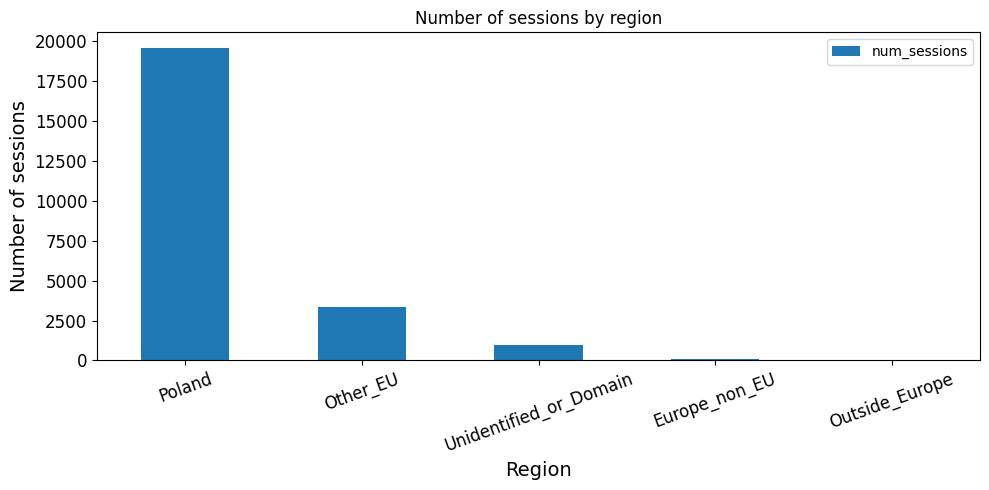

In [8]:
# Number of sessions and clicks by region

region_activity = (
    df_eda.groupBy("region")
    .agg(
        F.count("*").alias("num_clicks"),
        F.countDistinct("session_id").alias("num_sessions"),
        F.round(F.count("*") / F.countDistinct("session_id"), 2).alias("avg_clicks_per_session")
    )
    .orderBy(F.desc("num_sessions"))
)

region_activity.show(truncate=False)

pdf = region_activity.toPandas()

plot_df(
    pdf,
    x="region",
    y="num_sessions",
    kind="bar",
    figsize=(10, 5),
    xlabel="Region",
    ylabel="Number of sessions",
    title="Number of sessions by region",
    rotation=20
)

- Are trousers, skirts, blouses, or sale items viewed most?
- Which category attracts the most attention?

+--------------------+-------------+----------+------------+
|page_1_main_category|category_name|num_clicks|num_sessions|
+--------------------+-------------+----------+------------+
|1                   |trousers     |49742     |13082       |
|4                   |sale         |38747     |9192        |
|3                   |blouses      |38577     |10724       |
|2                   |skirts       |38408     |11490       |
+--------------------+-------------+----------+------------+



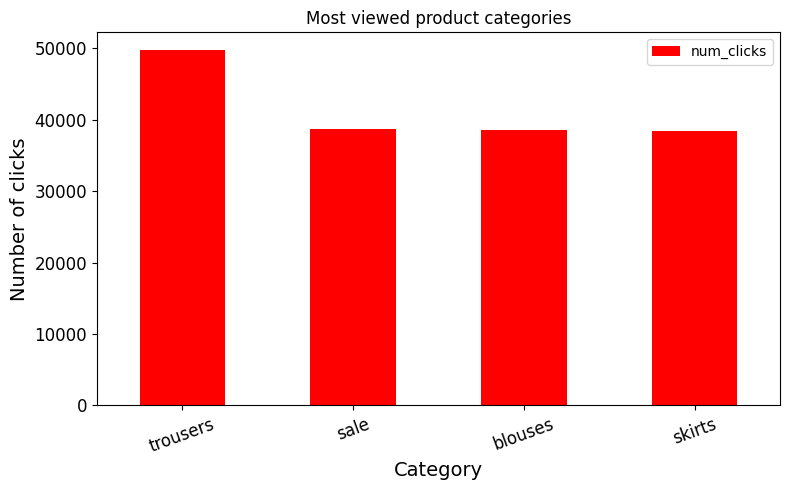

In [9]:
# Overall category popularity

category_popularity = (
    df_eda.groupBy("page_1_main_category", "category_name")
    .agg(
        F.count("*").alias("num_clicks"),
        F.countDistinct("session_id").alias("num_sessions")
    )
    .orderBy(F.desc("num_clicks"))
)

category_popularity.show(truncate=False)

pdf = category_popularity.toPandas()

plot_df(
    pdf,
    x="category_name",
    y="num_clicks",
    kind="bar",
    figsize=(8, 5),
    xlabel="Category",
    ylabel="Number of clicks",
    title="Most viewed product categories",
    rotation=20,
    color="red"
)

- Do users from different regions prefer different categories?
- For example, does Poland view different items than Outside Europe?

+----------------------+-------------+----------+
|region                |category_name|num_clicks|
+----------------------+-------------+----------+
|Europe_non_EU         |skirts       |161       |
|Europe_non_EU         |trousers     |153       |
|Europe_non_EU         |blouses      |141       |
|Europe_non_EU         |sale         |89        |
|Other_EU              |trousers     |10943     |
|Other_EU              |blouses      |7770      |
|Other_EU              |skirts       |5982      |
|Other_EU              |sale         |1913      |
|Outside_Europe        |trousers     |74        |
|Outside_Europe        |blouses      |54        |
|Outside_Europe        |skirts       |43        |
|Outside_Europe        |sale         |25        |
|Poland                |trousers     |37145     |
|Poland                |sale         |36084     |
|Poland                |skirts       |31123     |
|Poland                |blouses      |29611     |
|Unidentified_or_Domain|trousers     |1427      |


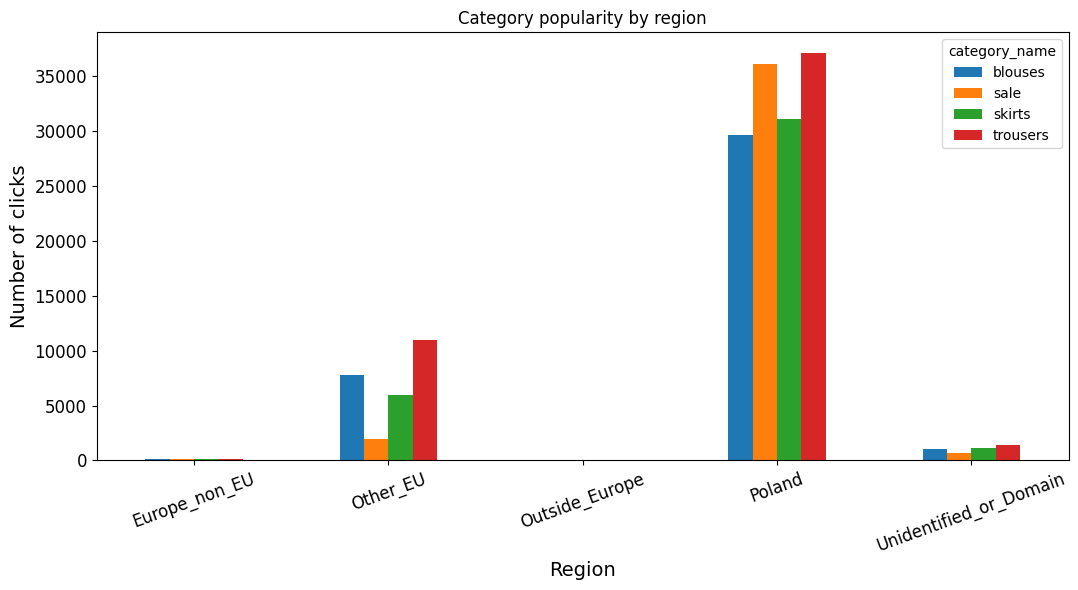

In [10]:
# Category popularity by region

category_by_region = (
    df_eda.groupBy("region", "category_name")
    .agg(F.count("*").alias("num_clicks"))
    .orderBy("region", F.desc("num_clicks"))
)

category_by_region.show(50, truncate=False)

pdf = category_by_region.toPandas()

pivot = pdf.pivot(
    index="region",
    columns="category_name",
    values="num_clicks"
).fillna(0)

plot_df(
    pivot,
    kind="bar",
    figsize=(11, 6),
    xlabel="Region",
    ylabel="Number of clicks",
    title="Category popularity by region",
    rotation=20
)

- Which exact clothing models receive the most attention?

+---------------------+----------+------------+
|page_2_clothing_model|num_clicks|num_sessions|
+---------------------+----------+------------+
|B4                   |3579      |3212        |
|A2                   |3013      |2557        |
|A11                  |2789      |2454        |
|P1                   |2681      |2266        |
|B10                  |2566      |2415        |
|A4                   |2522      |2224        |
|A15                  |2489      |2227        |
|A5                   |2354      |1949        |
|A10                  |2280      |1808        |
|A1                   |2265      |2104        |
+---------------------+----------+------------+



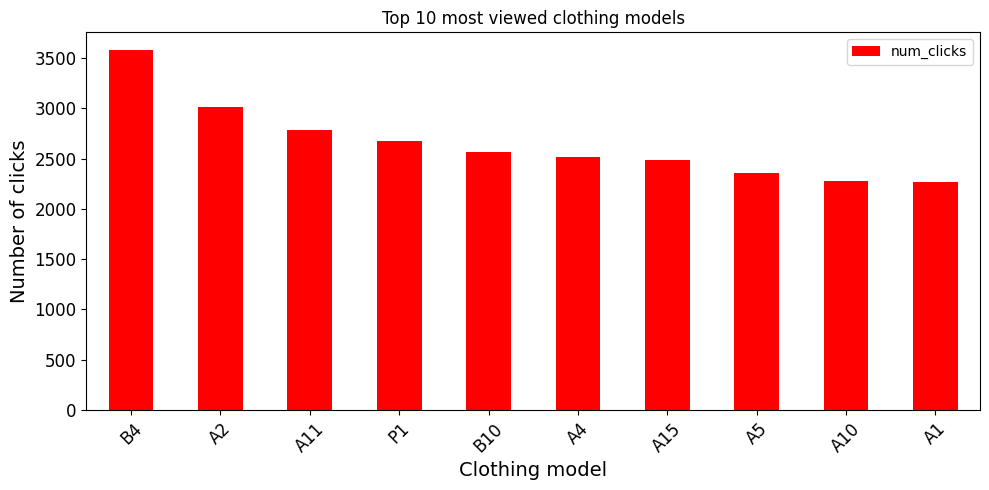

In [11]:
# Top 10 clothing models overall

top_products = (
    df_eda.groupBy("page_2_clothing_model")
    .agg(
        F.count("*").alias("num_clicks"),
        F.countDistinct("session_id").alias("num_sessions")
    )
    .orderBy(F.desc("num_clicks"))
    .limit(10)
)

top_products.show(truncate=False)

pdf = top_products.toPandas()

plot_df(
    pdf,
    x="page_2_clothing_model",
    y="num_clicks",
    kind="bar",
    figsize=(10, 5),
    xlabel="Clothing model",
    ylabel="Number of clicks",
    title="Top 10 most viewed clothing models",
    rotation=45,
    color="red"
)

- What are the top products in Poland?
- What are the top products in Other EU?
- Are the same products popular everywhere?

In [12]:
# Top 5 products per region

product_counts_region = (
    df_eda.groupBy("region", "page_2_clothing_model")
    .agg(F.count("*").alias("num_clicks"))
)

w = Window.partitionBy("region").orderBy(F.desc("num_clicks"))

top5_products_region = (
    product_counts_region
    .withColumn("rank", F.row_number().over(w))
    .filter(F.col("rank") <= 5)
    .orderBy("region", "rank")
)

top5_products_region.show(100, truncate=False)

+----------------------+---------------------+----------+----+
|region                |page_2_clothing_model|num_clicks|rank|
+----------------------+---------------------+----------+----+
|Europe_non_EU         |B10                  |14        |1   |
|Europe_non_EU         |A37                  |13        |2   |
|Europe_non_EU         |A15                  |10        |3   |
|Europe_non_EU         |B4                   |10        |4   |
|Europe_non_EU         |B27                  |9         |5   |
|Other_EU              |A2                   |627       |1   |
|Other_EU              |A5                   |607       |2   |
|Other_EU              |A11                  |577       |3   |
|Other_EU              |A12                  |573       |4   |
|Other_EU              |A10                  |539       |5   |
|Outside_Europe        |A21                  |10        |1   |
|Outside_Europe        |A15                  |7         |2   |
|Outside_Europe        |B24                  |6        

- Which colours get the most clicks?
- Are black, blue, red, etc. more popular than other colours?

+------+-----------+----------+------------+
|colour|colour_name|num_clicks|num_sessions|
+------+-----------+----------+------------+
|2     |black      |29764     |11968       |
|3     |blue       |29259     |10945       |
|6     |gray       |17476     |8986        |
|4     |brown      |16517     |8512        |
|14    |white      |15939     |7878        |
|9     |many colors|13531     |7096        |
|12    |red        |8830      |5964        |
|1     |beige      |7785      |4634        |
|7     |green      |6876      |4664        |
|13    |violet     |6295      |4224        |
|11    |pink       |5292      |3920        |
|10    |olive      |3579      |3212        |
|8     |navy blue  |2664      |2440        |
|5     |burgundy   |1667      |1315        |
+------+-----------+----------+------------+



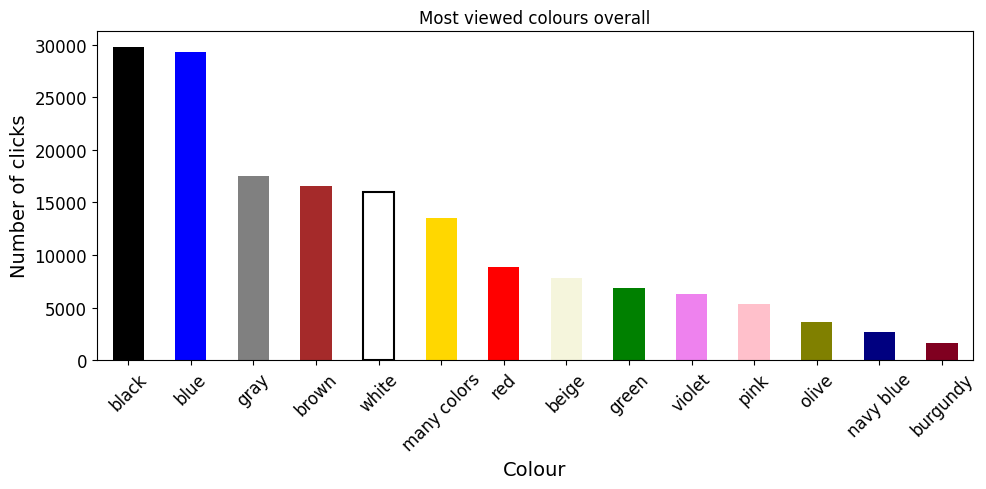

In [13]:
# Overall colour popularity

colour_popularity = (
    df_eda.groupBy("colour", "colour_name")
    .agg(
        F.count("*").alias("num_clicks"),
        F.countDistinct("session_id").alias("num_sessions")
    )
    .orderBy(F.desc("num_clicks"))
)

colour_popularity.show(truncate=False)

pdf = colour_popularity.toPandas()

bar_colors = [
    plot_colour_map.get(c, "lightgray")
    for c in pdf["colour_name"]
]

ax = pdf.plot(
    x="colour_name",
    y="num_clicks",
    kind="bar",
    figsize=(10, 5),
    color=bar_colors,
    legend=False
)

# Add black border only to the white bar
for bar, colour_name in zip(ax.patches, pdf["colour_name"]):
    if colour_name == "white":
        bar.set_edgecolor("black")
        bar.set_linewidth(1.5)

ax.set_xlabel("Colour", fontsize=14)
ax.set_ylabel("Number of clicks", fontsize=14)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

ax.set_title("Most viewed colours overall")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Do colour preferences differ by region?
- For example, is black popular everywhere or only in specific regions?

+----------------------+------+-----------+----------+----+
|region                |colour|colour_name|num_clicks|rank|
+----------------------+------+-----------+----------+----+
|Europe_non_EU         |2     |black      |129       |1   |
|Europe_non_EU         |3     |blue       |72        |2   |
|Europe_non_EU         |6     |gray       |60        |3   |
|Europe_non_EU         |14    |white      |51        |4   |
|Europe_non_EU         |9     |many colors|48        |5   |
|Other_EU              |3     |blue       |5721      |1   |
|Other_EU              |2     |black      |4355      |2   |
|Other_EU              |6     |gray       |2794      |3   |
|Other_EU              |14    |white      |2368      |4   |
|Other_EU              |4     |brown      |2156      |5   |
|Outside_Europe        |2     |black      |31        |1   |
|Outside_Europe        |1     |beige      |24        |2   |
|Outside_Europe        |4     |brown      |21        |3   |
|Outside_Europe        |3     |blue     

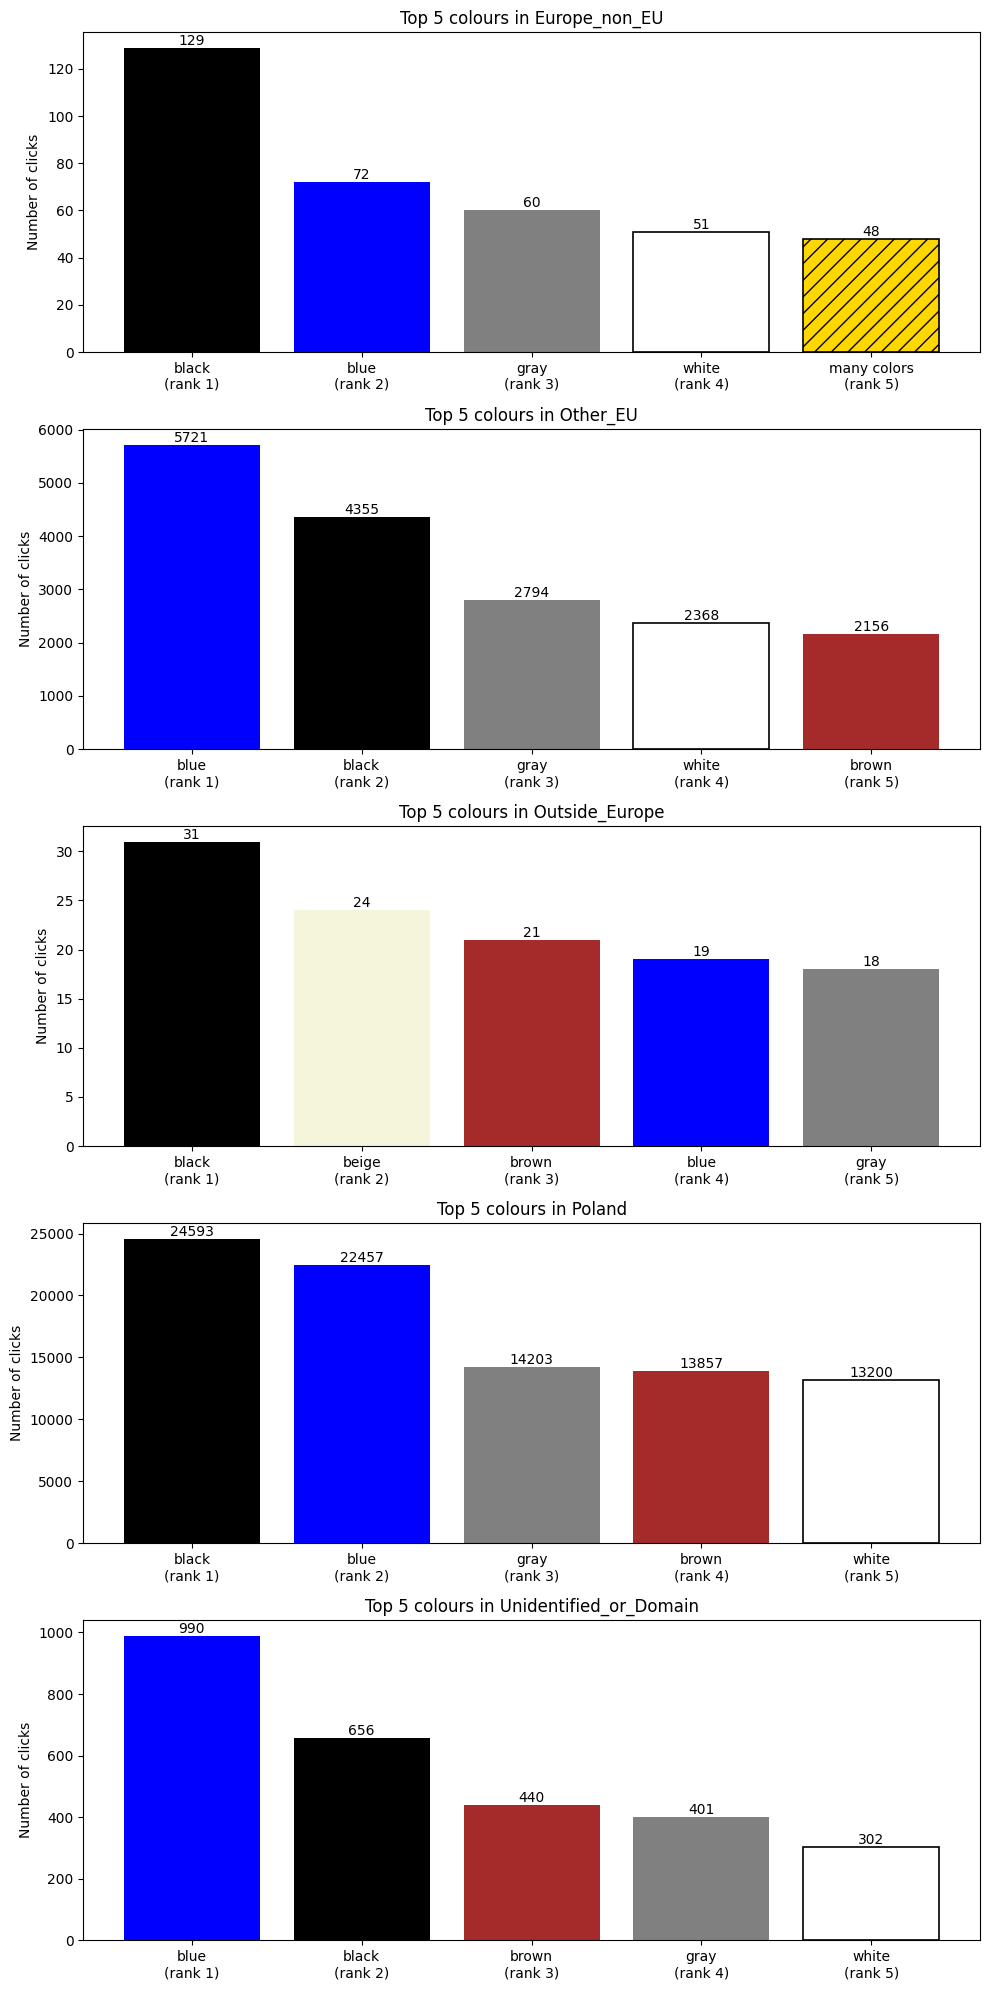

In [14]:
# %%
# Top 5 colours per region

colour_counts_region = (
    df_eda.groupBy("region", "colour", "colour_name")
    .agg(F.count("*").alias("num_clicks"))
)

w = Window.partitionBy("region").orderBy(F.desc("num_clicks"))

top5_colours_region = (
    colour_counts_region
    .withColumn("rank", F.row_number().over(w))
    .filter(F.col("rank") <= 5)
    .orderBy("region", "rank")
)

top5_colours_region.show(100, truncate=False)

pdf = top5_colours_region.toPandas()

def plot_top5_colours_by_region(pdf):
    regions = pdf["region"].unique()
    n = len(regions)

    fig, axes = plt.subplots(n, 1, figsize=(10, 4 * n))

    if n == 1:
        axes = [axes]

    for ax, region in zip(axes, regions):
        sub = pdf[pdf["region"] == region].sort_values("rank")

        colors = [
            plot_colour_map.get(c, "lightgray")
            for c in sub["colour_name"]
        ]

        labels = [
            f"{row['colour_name']}\n(rank {row['rank']})"
            for _, row in sub.iterrows()
        ]

        bars = ax.bar(labels, sub["num_clicks"], color=colors)

        ax.set_title(f"Top 5 colours in {region}")
        ax.set_ylabel("Number of clicks")

        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                str(int(height)),
                ha="center",
                va="bottom"
            )

        for bar, (_, row) in zip(bars, sub.iterrows()):
            if row["colour_name"] == "white":
                bar.set_edgecolor("black")
                bar.set_linewidth(1.2)
            if row["colour_name"] == "many colors":
                bar.set_hatch("//")
                bar.set_edgecolor("black")
                bar.set_linewidth(1.2)

    plt.tight_layout()
    plt.show()

plot_top5_colours_by_region(pdf)

- Are users mostly viewing cheap, medium, or expensive items?
- What is the typical viewed price?

+---------+--------+------------+--------+---------+------------------+
|min_price|q1_price|median_price|q3_price|max_price|avg_price         |
+---------+--------+------------+--------+---------+------------------+
|18       |33      |43          |52      |82       |43.802506738218696|
+---------+--------+------------+--------+---------+------------------+



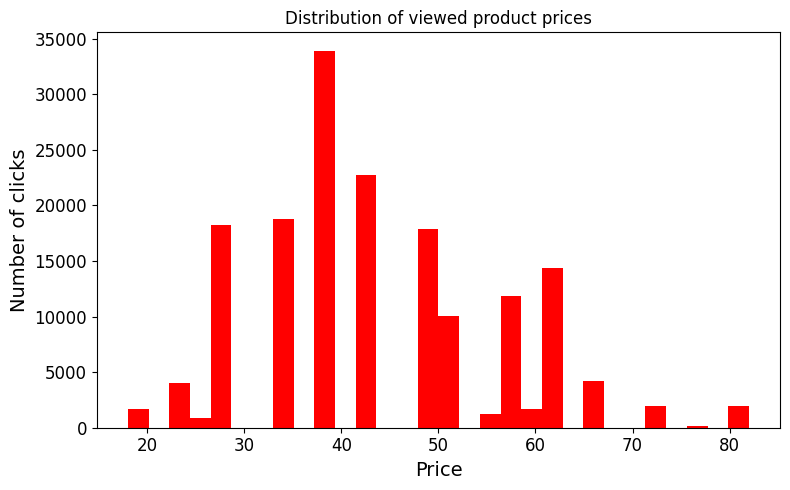

In [15]:
# Price distribution

price_summary = df_eda.agg(
    F.min("price").alias("min_price"),
    F.expr("percentile_approx(price, 0.25)").alias("q1_price"),
    F.expr("percentile_approx(price, 0.50)").alias("median_price"),
    F.expr("percentile_approx(price, 0.75)").alias("q3_price"),
    F.max("price").alias("max_price"),
    F.avg("price").alias("avg_price")
)

price_summary.show(truncate=False)

pdf = df_eda.select("price").toPandas()

ax = pdf["price"].plot(
    kind="hist",
    bins=30,
    figsize=(8, 5), color="red"
)

ax.set_xlabel("Price", fontsize=14)
ax.set_ylabel("Number of clicks", fontsize=14)
ax.set_title("Distribution of viewed product prices")

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.show()

- Are users price-sensitive?
- Which regions view more expensive products?
- Which regions view cheaper products?

In [16]:
# Above-average price preference overall

price_preference_overall = df_eda.agg(
    F.avg(F.col("price_2").cast("int")).alias("share_above_avg_price_views"),
    F.avg("price").alias("avg_viewed_price")
)

price_preference_overall.show(truncate=False)

+---------------------------+------------------+
|share_above_avg_price_views|avg_viewed_price  |
+---------------------------+------------------+
|0.5118326746195777         |43.802506738218696|
+---------------------------+------------------+



+--------------------+---------------------+------------------+
|              region|share_above_avg_price|         avg_price|
+--------------------+---------------------+------------------+
|       Europe_non_EU|   0.5496323529411765|45.064338235294116|
|      Outside_Europe|   0.5255102040816326| 45.10204081632653|
|Unidentified_or_D...|    0.515013211626231|44.835455200576504|
|              Poland|   0.5148660451020057|43.470592626322194|
|            Other_EU|   0.4951894167167769|45.276608538785325|
+--------------------+---------------------+------------------+



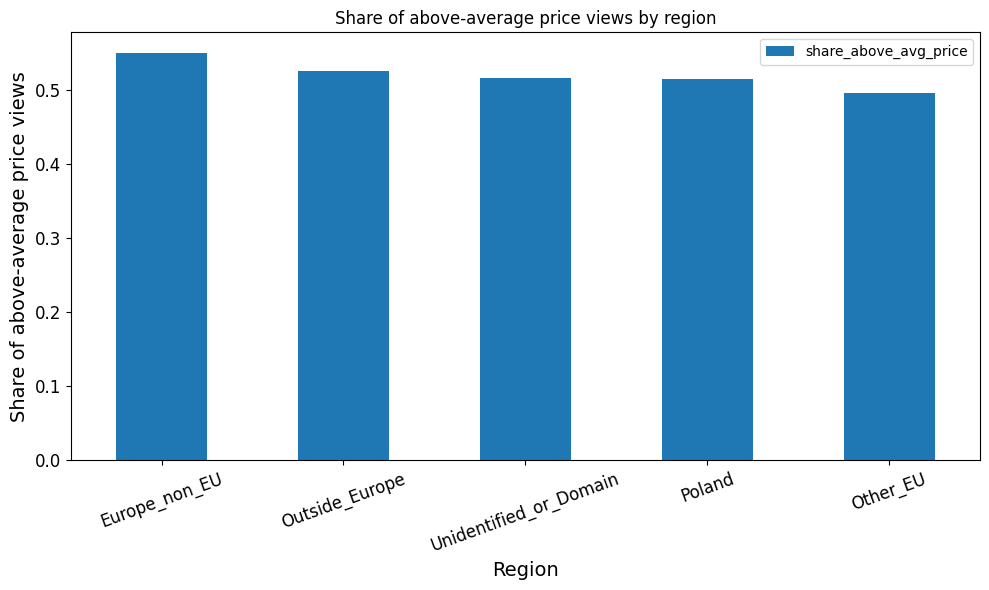

In [17]:
# above-average price preference by region
price_pref = (
    df.groupBy("region")
    .agg(
        F.avg(F.col("price_2").cast("int")).alias("share_above_avg_price"),
        F.avg("price").alias("avg_price"),
    )
    .orderBy(F.desc("share_above_avg_price"))
)
price_pref.show()

pdf = price_pref.toPandas()
plot_df(
    pdf,
    x="region",
    y="share_above_avg_price",
    kind="bar",
    figsize=(10, 6),
    xlabel="Region",
    ylabel=("Share of above-average price views"),
    title="Share of above-average price views by region",
    rotation=20,
)

- Do users browse deeply or leave early?
- How many sessions stop at page 1?

In [18]:
# Session depth summary

session_depth_summary = session_df.agg(
    F.avg("num_clicks").alias("avg_clicks_per_session"),
    F.expr("percentile_approx(num_clicks, 0.5)").alias("median_clicks_per_session"),
    F.avg("max_page").alias("avg_max_page"),
    F.expr("percentile_approx(max_page, 0.5)").alias("median_max_page"),
    F.avg(F.when(F.col("max_page") == 1, 1).otherwise(0)).alias("share_page1_only_sessions")
)

session_depth_summary.show(truncate=False)

+----------------------+-------------------------+------------------+---------------+-------------------------+
|avg_clicks_per_session|median_clicks_per_session|avg_max_page      |median_max_page|share_page1_only_sessions|
+----------------------+-------------------------+------------------+---------------+-------------------------+
|6.8872887704986265    |4                        |2.2502705402480645|2              |0.3963206526263215       |
+----------------------+-------------------------+------------------+---------------+-------------------------+



+--------+------------+
|max_page|num_sessions|
+--------+------------+
|1       |9522        |
|2       |5379        |
|3       |4346        |
|4       |3148        |
|5       |1631        |
+--------+------------+



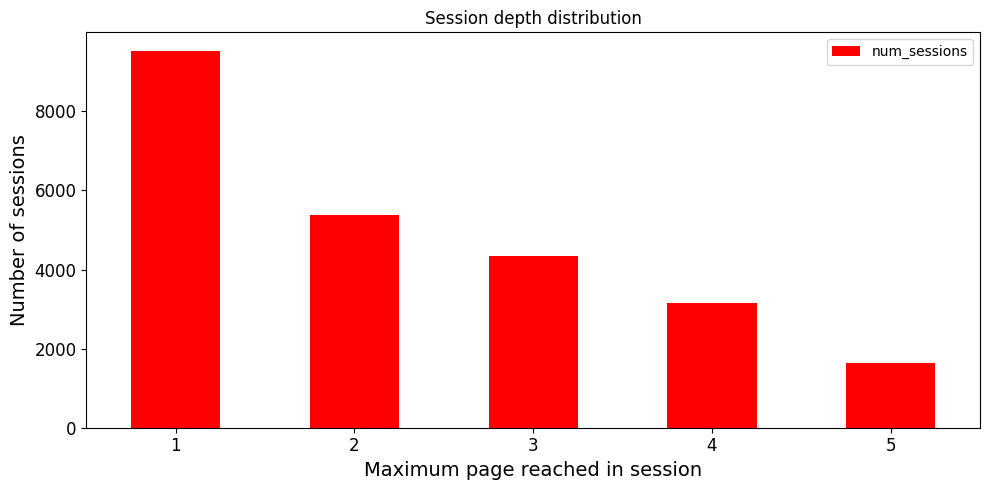

In [19]:
# Distribution of max page reached per session

page_depth_distribution = (
    session_df.groupBy("max_page")
    .agg(F.count("*").alias("num_sessions"))
    .orderBy("max_page")
)

page_depth_distribution.show(50, truncate=False)

pdf = page_depth_distribution.toPandas()

plot_df(
    pdf,
    x="max_page",
    y="num_sessions",
    kind="bar",
    figsize=(10, 5),
    xlabel="Maximum page reached in session",
    ylabel="Number of sessions",
    title="Session depth distribution",
    rotation=0,
    color="red"
)

- Are most sessions short?
- Do users usually click only one or two products?
- Are there long browsing sessions?

+----------+------------+
|num_clicks|num_sessions|
+----------+------------+
|1         |5042        |
|2         |3320        |
|3         |2620        |
|4         |2037        |
|5         |1597        |
|6         |1398        |
|7         |1117        |
|8         |934         |
|9         |749         |
|10        |648         |
|11        |607         |
|12        |485         |
|13        |390         |
|14        |322         |
|15        |289         |
|16        |259         |
|17        |250         |
|18        |179         |
|19        |159         |
|20        |163         |
|21        |149         |
|22        |101         |
|23        |105         |
|24        |99          |
|25        |92          |
|26        |78          |
|27        |72          |
|28        |53          |
|29        |47          |
|30        |69          |
|31        |51          |
|32        |35          |
|33        |43          |
|34        |33          |
|35        |31          |
|36        |

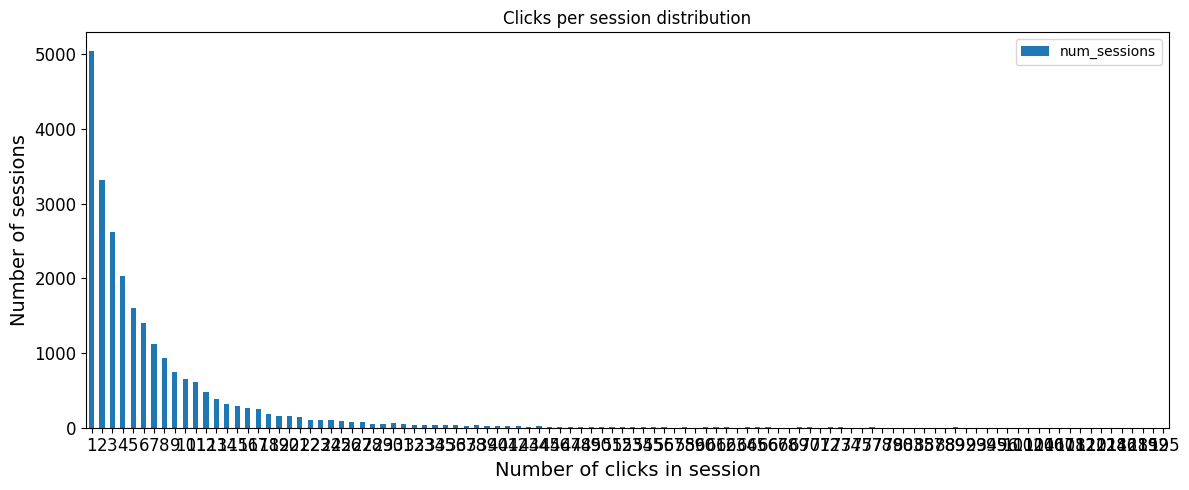

In [20]:
# Clicks per session distribution

clicks_per_session_distribution = (
    session_df.groupBy("num_clicks")
    .agg(F.count("*").alias("num_sessions"))
    .orderBy("num_clicks")
)

clicks_per_session_distribution.show(50, truncate=False)

pdf = clicks_per_session_distribution.toPandas()

plot_df(
    pdf,
    x="num_clicks",
    y="num_sessions",
    kind="bar",
    figsize=(12, 5),
    xlabel="Number of clicks in session",
    ylabel="Number of sessions",
    title="Clicks per session distribution",
    rotation=0
)

- Do users compare many products?
- Or do most sessions contain only a few product views?

+-------------------+------------+
|num_unique_products|num_sessions|
+-------------------+------------+
|1                  |5456        |
|2                  |3412        |
|3                  |2671        |
|4                  |2072        |
|5                  |1628        |
|6                  |1407        |
|7                  |1103        |
|8                  |875         |
|9                  |782         |
|10                 |649         |
|11                 |588         |
|12                 |451         |
|13                 |360         |
|14                 |313         |
|15                 |242         |
|16                 |232         |
|17                 |203         |
|18                 |169         |
|19                 |160         |
|20                 |165         |
|21                 |109         |
|22                 |88          |
|23                 |102         |
|24                 |66          |
|25                 |66          |
|26                 

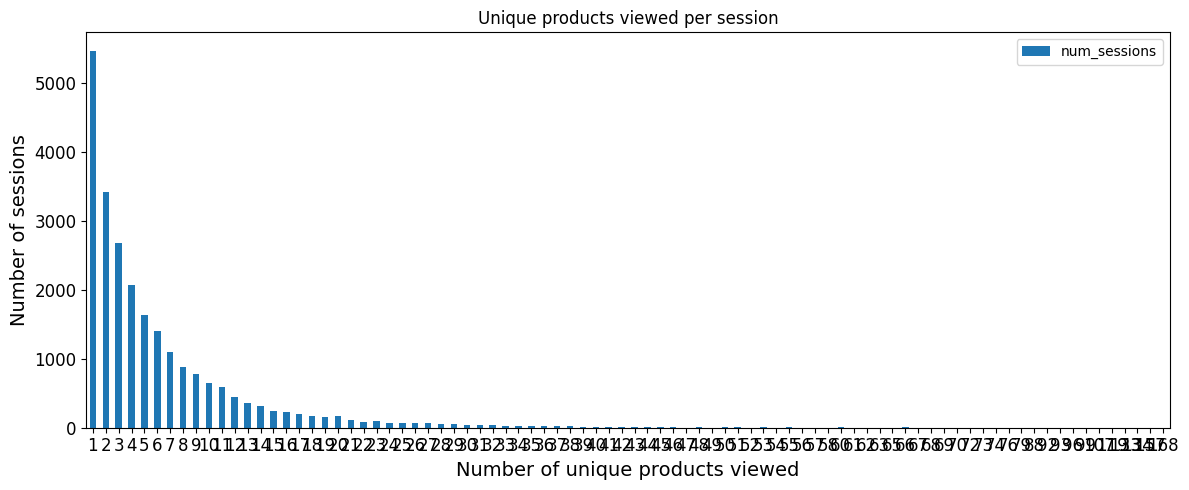

In [21]:
# Unique products per session

unique_products_distribution = (
    session_df.groupBy("num_unique_products")
    .agg(F.count("*").alias("num_sessions"))
    .orderBy("num_unique_products")
)

unique_products_distribution.show(50, truncate=False)

pdf = unique_products_distribution.toPandas()

plot_df(
    pdf,
    x="num_unique_products",
    y="num_sessions",
    kind="bar",
    figsize=(12, 5),
    xlabel="Number of unique products viewed",
    ylabel="Number of sessions",
    title="Unique products viewed per session",
    rotation=0
)

- Are users who view skirts also viewing blouses?
- Are sale products viewed together with other categories?
- Which category combinations are common?

In [22]:
# Category baskets: unique categories per session

category_basket = (
    df_eda
    .select("session_id", "region", "category_name")
    .dropDuplicates(["session_id", "category_name"])
)

a = category_basket.alias("a")
b = category_basket.alias("b")

category_pairs = (
    a.join(
        b,
        on=[
            F.col("a.session_id") == F.col("b.session_id"),
            F.col("a.category_name") < F.col("b.category_name")
        ],
        how="inner"
    )
    .select(
        F.col("a.region").alias("region"),
        F.col("a.session_id").alias("session_id"),
        F.col("a.category_name").alias("category_A"),
        F.col("b.category_name").alias("category_B")
    )
)

category_pair_counts = (
    category_pairs.groupBy("region", "category_A", "category_B")
    .agg(F.countDistinct("session_id").alias("pair_sessions"))
)

region_session_counts = (
    category_basket.groupBy("region")
    .agg(F.countDistinct("session_id").alias("num_sessions"))
)

category_item_counts = (
    category_basket.groupBy("region", "category_name")
    .agg(F.countDistinct("session_id").alias("category_sessions"))
)

category_rules = (
    category_pair_counts
    .join(region_session_counts, on="region")
    .join(
        category_item_counts
        .withColumnRenamed("category_name", "category_A")
        .withColumnRenamed("category_sessions", "category_A_sessions"),
        on=["region", "category_A"]
    )
    .join(
        category_item_counts
        .withColumnRenamed("category_name", "category_B")
        .withColumnRenamed("category_sessions", "category_B_sessions"),
        on=["region", "category_B"]
    )
    .withColumn("support", F.col("pair_sessions") / F.col("num_sessions"))
    .withColumn("confidence_A_to_B", F.col("pair_sessions") / F.col("category_A_sessions"))
    .withColumn("confidence_B_to_A", F.col("pair_sessions") / F.col("category_B_sessions"))
    .withColumn(
        "lift_A_to_B",
        F.col("confidence_A_to_B") / (F.col("category_B_sessions") / F.col("num_sessions"))
    )
    .orderBy(F.desc("support"))
)

category_rules.show(50, truncate=False)

+----------------------+----------+----------+-------------+------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+
|region                |category_B|category_A|pair_sessions|num_sessions|category_A_sessions|category_B_sessions|support            |confidence_A_to_B  |confidence_B_to_A  |lift_A_to_B       |
+----------------------+----------+----------+-------------+------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+
|Europe_non_EU         |trousers  |blouses   |28           |79          |40                 |55                 |0.35443037974683544|0.7                |0.509090909090909  |1.0054545454545454|
|Other_EU              |trousers  |blouses   |1115         |3372        |1753               |2264               |0.3306642941874259 |0.6360524814603536 |0.4924911660777385 |0.9473361163799967|
|Europe_non_EU         |trousers  |

- Which products are commonly viewed in the same session?
- Which products could be recommended together?

In [23]:
# One selected category association rule for Poland
# Rule: blouses -> trousers

selected_rule_poland = (
    category_rules
    .filter(F.col("region") == "Poland")
    .filter(F.col("category_A") == "blouses")
    .filter(F.col("category_B") == "trousers")
    .select(
        "region",
        F.col("category_A").alias("antecedent"),
        F.col("category_B").alias("consequent"),
        "pair_sessions",
        "num_sessions",
        F.round("support", 4).alias("support"),
        F.round("confidence_A_to_B", 4).alias("confidence"),
        F.round("lift_A_to_B", 4).alias("lift")
    )
)

selected_rule_poland.show(truncate=False)

+------+----------+----------+-------------+------------+-------+----------+------+
|region|antecedent|consequent|pair_sessions|num_sessions|support|confidence|lift  |
+------+----------+----------+-------------+------------+-------+----------+------+
|Poland|blouses   |trousers  |4571         |19582       |0.2334 |0.5391    |1.0328|
+------+----------+----------+-------------+------------+-------+----------+------+



In [24]:
basket_df = df.select("session_id", "region", "page_2_clothing_model").dropDuplicates(
    ["session_id", "page_2_clothing_model"]
)
basket_df.show(5)

+----------+------+---------------------+
|session_id|region|page_2_clothing_model|
+----------+------+---------------------+
|         1|Poland|                  A13|
|         1|Poland|                  A16|
|         1|Poland|                  B17|
|         1|Poland|                   B4|
|         1|Poland|                   B8|
+----------+------+---------------------+
only showing top 5 rows



In [25]:
a = basket_df.alias("a")
b = basket_df.alias("b")

pairs = a.join(
    b,
    on=[
        F.col("a.session_id") == F.col("b.session_id"),
        F.col("a.page_2_clothing_model") < F.col("b.page_2_clothing_model"),
    ],
    how="inner",
).select(
    F.col("a.region").alias(
        "region"
    ),  # note: I already checked there is no sessions in which country(region) changes
    F.col("a.page_2_clothing_model").alias("item_A"),
    F.col("b.page_2_clothing_model").alias("item_B"),
    F.col("a.session_id").alias("session_id"),
)  # note: checked for duplications, there are none
pairs.show(5)

+------+------+------+----------+
|region|item_A|item_B|session_id|
+------+------+------+----------+
|Poland|   A13|   B17|         1|
|Poland|   A13|    B4|         1|
|Poland|   A13|   P82|         1|
|Poland|   A13|   P67|         1|
|Poland|   A13|   C56|         1|
+------+------+------+----------+
only showing top 5 rows



In [26]:
pair_counts = (
    pairs.groupBy("region", "item_A", "item_B")
    .count()
    .withColumnRenamed("count", "pair_count")
)
session_counts = basket_df.groupBy("region").agg(
    F.countDistinct("session_id").alias("num_sessions")
)
item_counts = (
    basket_df.groupBy("region", "page_2_clothing_model")
    .agg(F.countDistinct("session_id").alias("item_sessions"))
    .withColumnRenamed("page_2_clothing_model", "item")
)

print("pair_counts:")
pair_counts.show(5)

print("session_counts:")
session_counts.show(5)

print("item_counts:")
item_counts.show(5)

pair_counts:


+--------+------+------+----------+
|  region|item_A|item_B|pair_count|
+--------+------+------+----------+
|Other_EU|   C34|   C49|        32|
|Other_EU|   B13|   B23|        40|
|Other_EU|   B26|   C47|         9|
|  Poland|   A35|   C53|        23|
|  Poland|    A2|    P2|       246|
+--------+------+------+----------+
only showing top 5 rows

session_counts:
+--------------------+------------+
|              region|num_sessions|
+--------------------+------------+
|       Europe_non_EU|          79|
|            Other_EU|        3372|
|      Outside_Europe|          34|
|Unidentified_or_D...|         959|
|              Poland|       19582|
+--------------------+------------+

item_counts:
+--------------------+----+-------------+
|              region|item|item_sessions|
+--------------------+----+-------------+
|            Other_EU|  P5|           22|
|Unidentified_or_D...| A38|            8|
|Unidentified_or_D...| P30|            5|
|            Other_EU| B20|           38|
|Un

In [27]:
rules = (
    pair_counts.join(session_counts, on="region")
    .join(
        item_counts.withColumnRenamed("item", "item_A").withColumnRenamed(
            "item_sessions", "item_A_sessions"
        ),
        on=["region", "item_A"],
    )
    .join(
        item_counts.withColumnRenamed("item", "item_B").withColumnRenamed(
            "item_sessions", "item_B_sessions"
        ),
        on=["region", "item_B"],
    )
    .withColumn("support", F.col("pair_count") / F.col("num_sessions"))
    .withColumn("confidence_A_to_B", F.col("pair_count") / F.col("item_A_sessions"))
    .withColumn("confidence_B_to_A", F.col("pair_count") / F.col("item_B_sessions"))
    .withColumn(
        "lift_A_to_B",
        (F.col("pair_count") / F.col("item_A_sessions"))
        / (F.col("item_B_sessions") / F.col("num_sessions")),
    )
    .orderBy(F.desc("support"))
)

rules.where(F.col("region")=="Poland").show(10, truncate=False)

+------+------+------+----------+------------+---------------+---------------+--------------------+-------------------+-------------------+------------------+
|region|item_B|item_A|pair_count|num_sessions|item_A_sessions|item_B_sessions|support             |confidence_A_to_B  |confidence_B_to_A  |lift_A_to_B       |
+------+------+------+----------+------------+---------------+---------------+--------------------+-------------------+-------------------+------------------+
|Poland|B13   |B10   |743       |19582       |2048           |1521           |0.037943008885711366|0.36279296875      |0.48849441157133466|4.670750765327087 |
|Poland|A2    |A1    |663       |19582       |1670           |1947           |0.03385762434889184 |0.3970059880239521 |0.3405238828967643 |3.9928974101104417|
|Poland|A2    |A11   |629       |19582       |1912           |1947           |0.03212133592074354 |0.32897489539748953|0.32306111967128914|3.308673036298736 |
|Poland|A5    |A2    |615       |19582       |

In [28]:
# Strong product association rules

strong_product_rules = (
    rules
    .filter(F.col("pair_count") >= 5)
    .filter(F.col("support") > 0)
    .orderBy(F.desc("lift_A_to_B"), F.desc("confidence_A_to_B"))
)

strong_product_rules.select(
    "region",
    "item_A",
    "item_B",
    "pair_count",
    "support",
    "confidence_A_to_B",
    "lift_A_to_B"
).show(50, truncate=False)

+----------------------+------+------+----------+---------------------+-------------------+------------------+
|region                |item_A|item_B|pair_count|support              |confidence_A_to_B  |lift_A_to_B       |
+----------------------+------+------+----------+---------------------+-------------------+------------------+
|Other_EU              |P73   |P75   |5         |0.0014827995255041518|0.38461538461538464|162.1153846153846 |
|Other_EU              |P45   |P65   |5         |0.0014827995255041518|0.8333333333333334 |140.5             |
|Other_EU              |P58   |P67   |5         |0.0014827995255041518|0.4166666666666667 |108.07692307692308|
|Other_EU              |P44   |P51   |5         |0.0014827995255041518|0.5                |105.37499999999999|
|Other_EU              |P19   |P30   |6         |0.0017793594306049821|0.42857142857142855|103.22448979591837|
|Other_EU              |P41   |P72   |5         |0.0014827995255041518|0.45454545454545453|102.18181818181817|
|

In [29]:
# Strong product rules for Poland

strong_product_rules_poland = (
    rules
    .filter(F.col("region") == "Poland")
    .filter(F.col("pair_count") >= 5)
    .orderBy(F.desc("lift_A_to_B"), F.desc("confidence_A_to_B"))
)

strong_product_rules_poland.select(
    "item_A",
    "item_B",
    "pair_count",
    "support",
    "confidence_A_to_B",
    "lift_A_to_B"
).show(30, truncate=False)

+------+------+----------+---------------------+-------------------+------------------+
|item_A|item_B|pair_count|support              |confidence_A_to_B  |lift_A_to_B       |
+------+------+----------+---------------------+-------------------+------------------+
|P31   |P32   |21        |0.0010724134409151262|0.3                |67.52413793103447 |
|P24   |P31   |25        |0.0012766826677561025|0.20161290322580644|56.39976958525345 |
|P27   |P31   |28        |0.0014298845878868349|0.19444444444444445|54.394444444444446|
|P32   |P66   |9         |4.5960576039219694E-4|0.10344827586206896|49.40790580319596 |
|P24   |P32   |27        |0.0013788172811765908|0.21774193548387097|49.00945494994438 |
|P58   |P66   |14        |7.149422939434174E-4 |0.10144927536231885|48.453163662071404|
|P31   |P66   |7         |3.574711469717087E-4 |0.1                |47.7609756097561  |
|P45   |P66   |12        |6.128076805229292E-4 |0.09375            |44.77591463414634 |
|P66   |P76   |13        |6.6387

In [30]:
# Compact EDA summary for report

total_clicks = df_eda.count()
total_sessions = df_eda.select("session_id").distinct().count()

top_region = (
    region_activity
    .orderBy(F.desc("num_sessions"))
    .limit(1)
    .collect()[0]
)

top_category = (
    category_popularity
    .orderBy(F.desc("num_clicks"))
    .limit(1)
    .collect()[0]
)

top_colour = (
    colour_popularity
    .orderBy(F.desc("num_clicks"))
    .limit(1)
    .collect()[0]
)

session_summary_row = session_depth_summary.collect()[0]
price_summary_row = price_summary.collect()[0]

print("========== EDA BUSINESS INSIGHT SUMMARY ==========")
print(f"Total clicks: {total_clicks}")
print(f"Total sessions: {total_sessions}")
print(f"Top region by sessions: {top_region['region']} ({top_region['num_sessions']} sessions)")
print(f"Top category by clicks: {top_category['category_name']} ({top_category['num_clicks']} clicks)")
print(f"Top colour by clicks: {top_colour['colour_name']} ({top_colour['num_clicks']} clicks)")
print(f"Average clicks per session: {session_summary_row['avg_clicks_per_session']:.2f}")
print(f"Median clicks per session: {session_summary_row['median_clicks_per_session']}")
print(f"Average max page reached: {session_summary_row['avg_max_page']:.2f}")
print(f"Share of page-1-only sessions: {session_summary_row['share_page1_only_sessions']:.2%}")
print(f"Average viewed price: {price_summary_row['avg_price']:.2f}")
print(f"Median viewed price: {price_summary_row['median_price']}")
print("=================================================")

========== EDA BUSINESS INSIGHT SUMMARY ==========
Total clicks: 165474
Total sessions: 24026
Top region by sessions: Poland (19582 sessions)
Top category by clicks: trousers (49742 clicks)
Top colour by clicks: black (29764 clicks)
Average clicks per session: 6.89
Median clicks per session: 4
Average max page reached: 2.25
Share of page-1-only sessions: 39.63%
Average viewed price: 43.80
Median viewed price: 43
